# Cohere 재랭킹 실험

https://cohere.com/rerank

https://docs.cohere.com/docs/rerank

https://python.langchain.com/docs/integrations/retrievers/cohere-reranker/

Cohere(캐나다)는 기업용 AI, 자연어 처리, 검색 및 생성형 AI 분야에서 강력한 솔루션을 제공하는 플랫폼이다.

Command R, Embed, Rerank와 같은 모델을 통해, 문서 검색, 요약, 질의응답, 다국어 지원 등 다양한 업무 자동화 및 데이터 활용이 가능하다. 또한 API와 다양한 클라우드 환경 지원으로, 개발자와 기업이 쉽게 도입할 수 있는 것이 큰 장점이다.

## Bi-Encoder와 Cross-Encoder 비교

**Bi-Encoder**와 **Cross-Encoder**는 문장 쌍의 관계(예: 유사도, 연관성 등)를 계산할 때 사용하는 대표적인 두 가지 구조이다. 각각의 구조와 특징을 간단하게 비교하면 다음과 같다.

| 구조         | 입력 방식                                      | 연산 속도         | 성능(정확도)         | 특징 요약                        |
|:------------:|:---------------------------------------------:|:----------------:|:--------------------:|:-------------------------------:|
| **Bi-Encoder**   | 두 문장을 각각 독립적으로 임베딩                | 빠름              | 다소 낮음             | 임베딩 미리 계산/저장 가능, 대량 비교 적합 |
| **Cross-Encoder**| 두 문장을 [SEP]으로 연결해 한 번에 입력           | 느림              | 높음                  | 문장 간 상호작용 정보 최대 활용, 소규모 비교 적합 |

**설명**

- **Bi-Encoder**  
  - 두 문장을 각각 독립적으로 인코더(BERT 등)에 넣어 임베딩 벡터를 만든다.
  - 만들어진 임베딩 벡터끼리 코사인 유사도 등으로 비교한다.
  - 임베딩을 미리 계산해 둘 수 있으므로, 대규모 문장 비교에서 매우 빠른 속도를 낼 수 있다.
  - 하지만 문장 간의 미세한 상호작용 정보가 손실될 수 있어, Cross-Encoder에 비해 정확도가 낮다.

- **Cross-Encoder**  
  - 두 문장을 [SEP] 토큰으로 연결해 한 번에 인코더에 넣는다.
  - 모델이 두 문장 사이의 상호작용 정보를 직접 활용해 결과(유사도 등)를 바로 출력한다.
  - 모든 문장 쌍마다 모델 연산이 필요하므로, 비교해야 할 문장이 많아질수록 속도가 매우 느려진다.
  - 하지만 문장 간 관계를 더욱 정확하게 파악할 수 있어, 성능(정확도)이 높다.

**정리**
- **Bi-Encoder**는 속도가 빠르지만, 성능(정확도)은 Cross-Encoder보다 낮다.
- **Cross-Encoder**는 성능이 뛰어나지만, 연산량이 많아 속도가 느리다.
- 실제로는 Bi-Encoder로 후보군을 먼저 빠르게 좁히고, Cross-Encoder로 최종 순위를 정하는 식으로 두 구조를 조합해 사용하는 경우가 많다.

**수식 예시**  
- Bi-Encoder에서 문장 임베딩 $u$, $v$를 얻고, 코사인 유사도는 다음과 같이 계산한다:
  $$
  \text{CosineSimilarity}(u, v) = \frac{u \cdot v}{\|u\|\|v\|}
  $$
  이 연산은 임베딩만 있으면 매우 빠르게 수행된다.

- Cross-Encoder는 두 문장을 [SEP]으로 연결해 입력한 뒤, 모델의 출력(예: [CLS] 토큰)을 통해 유사도를 바로 얻는다.

In [10]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')
os.environ['COHERE_API_KEY'] = os.getenv('COHERE_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [2]:
import pandas as pd

document_df = pd.read_csv('documents.csv')
queries_df = pd.read_csv('queries.csv')

queries_df

,query_id,query_text,relevant_doc_ids
0,Q1,제주도 올레길 트레킹 코스 추천,D1=3;D4=1;D30=1
1,Q2,전주 비빔밥 vs 진주 비빔밥 재료 및 맛 차이,D2=3
2,Q3,걸스데이 대표 히트곡 목록 알려줘,D3=3
3,Q4,훈민정음 창제 배경과 세종대왕의 의의,D4=3
4,Q5,이순신 장군이 명량 해전에서 사용한 전술은 무엇인가?,D5=3
5,Q6,2024년 기후 변화 주요 지표와 한국의 탄소 중립 정책,D6=3;D14=2;D26=1
6,Q7,한국 AI 윤리 이슈와 관련 정책 사례는?,D7=3;D25=2
7,Q8,서울 지하철 환승 시 T-money 사용 방법,D8=3
8,Q9,판소리 춘향가 줄거리와 공연 특징,D9=3
9,Q10,한국 축구 대표팀 2002년 한일 월드컵 4강 진출 이유,D10=3


In [3]:
from rank_bm25 import BM25Okapi
from kiwipiepy import Kiwi

kiwi = Kiwi()

def kiwi_tokenize(doc):
    return [token.form for token in kiwi.tokenize(doc)]
# 문서 내용 토큰화
tokenized_docs = [kiwi_tokenize(doc) for doc in document_df['content']]
bm25 = BM25Okapi(tokenized_docs) # BM25 모델 생성 (토큰화된 문서)
# 질의문을 토큰화해서 BM25로 상위 문서 검색하는 함수
def bm25_search(query, top_k=5):
    query_tokens = kiwi_tokenize(query)      # 검색어 토큰화
    scores = bm25.get_scores(query_tokens) # 각 문서의 BM25 점수 계산

    # 점수 기준 내림차순 정렬한 인덱스
    ranked_idx = sorted(range(len(scores)), key = lambda i: scores[i], reverse=True)
    retrieved_docs = [document_df['doc_id'].iloc[i] for i in ranked_idx[:top_k]]
    return retrieved_docs

bm25_search('제주도 관광 명소')

['D1', 'D2', 'D3', 'D4', 'D5']

In [4]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embeddings = OpenAIEmbeddings(model='text-embedding-3-small') # 1536차원 임베딩 모델
# 벡터스토어 연결
vector_store = PineconeVectorStore(
    index_name = 'ir', # 연결할 index명
    embedding = embeddings # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩 차원이 같아야함)
)

### cohere reranking

In [5]:
# reranking 후보군 설정
bm25_candidates = {}
dense_candidates = {}

for idx, row in queries_df.iterrows():
    qid = row['query_id']
    query_text = row['query_text']
    bm25_candidates[qid] = bm25_search(query_text, top_k=20)
    docs = vector_store.similarity_search(query_text, k=20)
    dense_candidates[qid] = [doc.metadata['doc_id'] for doc in docs]

print(bm25_candidates)
print(dense_candidates)

{'Q1': ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'D19', 'D20'], 'Q2': ['D13', 'D2', 'D1', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D14', 'D15', 'D16', 'D17', 'D18', 'D19', 'D20'], 'Q3': ['D2', 'D21', 'D14', 'D11', 'D28', 'D29', 'D23', 'D10', 'D24', 'D1', 'D4', 'D9', 'D3', 'D5', 'D6', 'D7', 'D8', 'D12', 'D13', 'D15'], 'Q4': ['D4', 'D9', 'D1', 'D30', 'D5', 'D3', 'D22', 'D15', 'D2', 'D6', 'D7', 'D8', 'D10', 'D11', 'D12', 'D13', 'D14', 'D16', 'D17', 'D18'], 'Q5': ['D5', 'D18', 'D19', 'D23', 'D15', 'D13', 'D28', 'D12', 'D11', 'D4', 'D14', 'D7', 'D26', 'D3', 'D22', 'D24', 'D21', 'D6', 'D29', 'D9'], 'Q6': ['D6', 'D27', 'D17', 'D25', 'D3', 'D14', 'D8', 'D15', 'D10', 'D9', 'D2', 'D1', 'D30', 'D5', 'D22', 'D4', 'D7', 'D11', 'D12', 'D13'], 'Q7': ['D27', 'D25', 'D7', 'D14', 'D9', 'D17', 'D10', 'D15', 'D2', 'D3', 'D20', 'D1', 'D30', 'D12', 'D29', 'D23', 'D19', 'D16', 'D8', 'D18'], 'Q8': ['D8', 'D18', 

In [6]:
# BM25 후보 + Dense 후보 병합 및 중복 제거
qid = 'Q1'
merged_candidates = bm25_candidates[qid] + dense_candidates[qid] # 후보 리스트 합치기
merged_candidates = list(set(merged_candidates)) # 중복 제거 (리스트 -> 셋 -> 리스트)
print(len(merged_candidates))
print(merged_candidates)

27
['D7', 'D3', 'D2', 'D9', 'D24', 'D21', 'D23', 'D13', 'D29', 'D1', 'D5', 'D15', 'D11', 'D14', 'D20', 'D10', 'D28', 'D18', 'D17', 'D27', 'D12', 'D8', 'D16', 'D19', 'D30', 'D4', 'D6']


In [16]:
from cohere import Client, TooManyRequestsError # Cohere 클라이언트 API, 예외처리
from tqdm.auto import tqdm
import time

co = Client() # Cohere 클라이언트 객체
# 쿼리와 후보 문서를 입력받아, Cohere rerank 결과를 반환하는 함수
def cohere_rerank(query, candidates, max_retries=1, wait_seconds=10):
    texts = [
        # 해당 doc_id를 이용해 document_df에서 본문내용 조회
        document_df.loc[document_df['doc_id'] == doc_id, 'content'].values[0] 
        for doc_id in candidates
    ]
    def call_rerank_api():
        # Cohere rerank API 호출
        response = co.rerank(
            model = 'rerank-multilingual-v3.0',
            query = query,    # 사용자 검색 쿼리
            documents = texts # 후보 문서 텍스트
        )
        rerank_index = sorted(response.results, key = lambda x: x.relevance_score, reverse=True)
        return [candidates[r.index] for r in rerank_index] # 재정렬된 qid로 doc_id를 리스트로 반환

    for attempt in range(max_retries + 1):
        try:
            return call_rerank_api() # api 호출 시도
        except TooManyRequestsError:
            if attempt < max_retries:
                print(f"TooManyRequestsError: {attempt + 1} / {max_retries + 1}\n"
                    f"{wait_seconds}초 후에 재시도합니다."
                )
                time.sleep(wait_seconds) # 지정 시간 대기 후 재시도
            # 최대 재시도 횟수 초과시 예외 전달
            else:
                raise

cohere_rerank('제주도 관광 명소', ['D7', 'D3', 'D2', 'D9', 'D24', 'D21', 'D23', 'D13', 'D29', 'D1', 'D5', 'D15', 'D11', 'D14', 'D20', 'D10', 'D28', 'D18', 'D17', 'D27', 'D12', 'D8', 'D16', 'D19', 'D30', 'D4', 'D6'] )

['D1',
 'D12',
 'D15',
 'D2',
 'D9',
 'D16',
 'D29',
 'D3',
 'D17',
 'D5',
 'D30',
 'D21',
 'D13',
 'D23',
 'D24',
 'D11',
 'D7',
 'D28',
 'D20',
 'D10',
 'D4',
 'D19',
 'D6',
 'D14',
 'D18',
 'D8',
 'D27']

### cohere_rerank 함수 부분검증

In [ ]:
print(merged_candidates) # 정렬되지 않은 후보군
print(cohere_rerank('제주도 관광 명소',merged_candidates)) # 정렬된 후보군

['D7', 'D3', 'D2', 'D9', 'D24', 'D21', 'D23', 'D13', 'D29', 'D1', 'D5', 'D15', 'D11', 'D14', 'D20', 'D10', 'D28', 'D18', 'D17', 'D27', 'D12', 'D8', 'D16', 'D19', 'D30', 'D4', 'D6']
['D27', 'D18', 'D8', 'D14', 'D6', 'D19', 'D4', 'D10', 'D20', 'D28', 'D7', 'D11', 'D24', 'D23', 'D13', 'D21', 'D30', 'D5', 'D17', 'D3', 'D29', 'D16', 'D9', 'D2', 'D15', 'D12', 'D1']


In [17]:
rerank_results = {}
top_k = 5

for idx, row in tqdm(queries_df.iterrows()):
    qid = row['query_id']
    query_text = row['query_text']
    # 후보군 병합 후 중복 제거
    merged_candidates = list(set(bm25_candidates[qid]+ dense_candidates[qid]))
    # rerank 함수 호출 후 상위 top_k개 저장
    rerank_results[qid] = cohere_rerank(query_text, merged_candidates)
    time.sleep(6)

rerank_results

0it [00:00, ?it/s]

TooManyRequestsError: 1 / 2
10초 후에 재시도합니다.
TooManyRequestsError: 1 / 2
10초 후에 재시도합니다.
TooManyRequestsError: 1 / 2
10초 후에 재시도합니다.
TooManyRequestsError: 1 / 2
10초 후에 재시도합니다.
TooManyRequestsError: 1 / 2
10초 후에 재시도합니다.
TooManyRequestsError: 1 / 2
10초 후에 재시도합니다.


{'Q1': ['D1',
  'D12',
  'D11',
  'D15',
  'D9',
  'D19',
  'D21',
  'D23',
  'D2',
  'D16',
  'D24',
  'D30',
  'D7',
  'D5',
  'D29',
  'D14',
  'D28',
  'D4',
  'D20',
  'D6',
  'D13',
  'D18',
  'D17',
  'D10',
  'D27',
  'D8',
  'D3'],
 'Q2': ['D13',
  'D2',
  'D11',
  'D15',
  'D4',
  'D16',
  'D12',
  'D29',
  'D9',
  'D22',
  'D5',
  'D21',
  'D1',
  'D6',
  'D3',
  'D10',
  'D20',
  'D23',
  'D17',
  'D7',
  'D14',
  'D18',
  'D28',
  'D24',
  'D19',
  'D27',
  'D8'],
 'Q3': ['D3',
  'D9',
  'D12',
  'D15',
  'D17',
  'D5',
  'D4',
  'D30',
  'D21',
  'D6',
  'D7',
  'D22',
  'D2',
  'D13',
  'D28',
  'D29',
  'D10',
  'D19',
  'D11',
  'D24',
  'D14',
  'D1',
  'D8',
  'D23',
  'D18',
  'D20',
  'D27'],
 'Q4': ['D4',
  'D9',
  'D15',
  'D16',
  'D2',
  'D3',
  'D5',
  'D22',
  'D10',
  'D12',
  'D17',
  'D28',
  'D25',
  'D18',
  'D1',
  'D26',
  'D11',
  'D7',
  'D14',
  'D8',
  'D13',
  'D30',
  'D29',
  'D6',
  'D27'],
 'Q5': ['D5',
  'D24',
  'D15',
  'D22',
  'D28',
  'D

In [18]:
import numpy as np

def parse_relevant(relevant_str) -> dict[str, int]:
    '''
    참조문서 답안 문자열을 dict로 파싱하는 함수

    relevant_str = "D1=3;D4=1;D30=1" -> {'D1': 3, 'D4': 1, 'D30': 1}
    '''
    pairs = relevant_str.split(';')
    rel_dict = {}

    for pair in pairs:
        doc_id, grade = pair.split('=')
        rel_dict[doc_id] = int(grade)
    return rel_dict
# 예측 결과와 실제 정답을 비교해서 평가지표를 계산하는 함수
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # Precision@k
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict]) # top-k 적중 개수
    precision = hits / k # 정밀도 = 맞춘갯수 / 전체갯수
    # Recall@k
    total_relevant = len(relevant_dict) # 전체 관련 문서 수
    recall = hits / total_relevant if total_relevant > 0 else 0 # 재현율 = 관련 문서 맞춘 수

    # MRR 예측치 중 첫 관련문서 순위 점수
    rr = 0 # 관련 문서 수
    # 전체 랭킹에서 첫번째 적중된 것을 찾음
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1) # 첫 적중 순위 역수
            break # 첫 번째 적중 rr 반영 후 break

    # AP (MAP를 위한 사전 계산)
    num_correct = 0 # 현재까지의 적중 횟수
    precisions = [] # 적중시의 precision
    for idx, doc in enumerate(predicted[:k]): # top-k 범위에서 
        if doc in relevant_dict:
            num_correct += 1
            precisions.append(num_correct / (idx + 1)) # 현재 시점의 precision 기록
    ap = np.mean(precisions) if precisions else 0 # precision 평균치 사용, 없으면 0

    return precision, recall, rr, ap
# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []

    for idx, row in queries_df.iterrows():
        qid = row['query_id']
        relevant_dict = parse_relevant(row['relevant_doc_ids']) # 정답 dict 파싱
        predicted = method_results[qid] # 해당 쿼리의 에측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k) # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap) 

    return {
        'P@k': np.mean(prec_list), # 쿼리 평균 Precision@k
        'R@k': np.mean(rec_list),  # 쿼리 평균 Recall@k
        'MRR': np.mean(rr_list),   # 쿼리 평균 MRR
        'MAP': np.mean(ap_list),   # 쿼리 평균 MAP
    }

In [ ]:
bm25_results = {qid: doc_ids[:5] for qid, doc_ids in bm25_candidates.items()}   # 상위 5개 추출
dense_results = {qid: doc_ids[:5] for qid, doc_ids in dense_candidates.items()} # 상위 5개 추출
# BM25 / Dense 결과로 P@5, R@5, MRR, MAP 계산
bm25_metrics = evaluate_all(bm25_results, queries_df, k=5)
dense_metrics = evaluate_all(dense_results, queries_df, k=5)
rerank_metrics = evaluate_all(rerank_results, queries_df, k=5)

In [20]:
metrics_df = pd.DataFrame({
    'Metrics': ['P@5', 'R@5', 'MRR', 'MAP'],
    'BM25': [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']],
    'Dense': [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']],
    'ReRank': [rerank_metrics['P@k'], rerank_metrics['R@k'], rerank_metrics['MRR'], rerank_metrics['MAP']]
})
metrics_df

,Metrics,BM25,Dense,ReRank
0,P@5,0.233333,0.246667,0.240000
1,R@5,0.838889,0.888889,0.877778
2,MRR,0.900000,0.950000,0.983333
3,MAP,0.874444,0.920556,0.966667


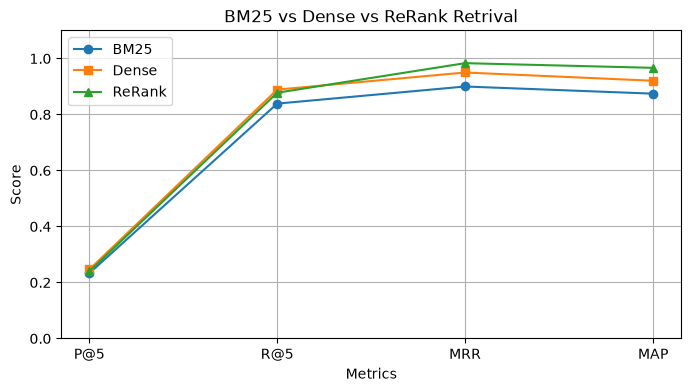

In [21]:
import matplotlib.pyplot as plt

metrics = ['P@5', 'R@5', 'MRR', 'MAP']
bm25_vals = [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']]
dense_vals = [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']]
rerank_vals = [rerank_metrics['P@k'], rerank_metrics['R@k'], rerank_metrics['MRR'], rerank_metrics['MAP']]

x = range(len(metrics))

plt.figure(figsize=(8, 4))
plt.plot(x, bm25_vals, marker='o', label='BM25')
plt.plot(x, dense_vals, marker='s', label='Dense')
plt.plot(x, rerank_vals, marker='^', label='ReRank')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('BM25 vs Dense vs ReRank Retrival')
plt.legend()
plt.grid()
plt.show()

### ReRank
- 전반적 성능 최고
    - ReRank는 P@5, R@5, MRR, MAP 전 지표에서 가장 안정적으로 높거나 최고 수준을 기록함.
- 초기 검색 한계 보완
    - BM25/Dense가 만든 후보군을 의미 기반으로 재정렬하면서, 상위 랭크의 품질이 확실히 개선됨.
- 특히 강한 지표
    - MRR / MAP에서 ReRank가 가장 높음 → 첫 정답을 더 앞에 배치하고 전반적인 랭킹 품질이 우수함.
    - R@5도 Dense와 비슷하거나 더 높아, 정답 회수력을 유지하면서 정렬 품질까지 향상.
- 결론적으로 BM25 + Dense로 후보를 넓게 뽑고, ReRank로 최종 정렬하는 파이프라인이 가장 효과적


##### 일반적인 사용법
1. 1차 검색 (Recall 단계)
- BM25
    - 장점: 빠름, 비용 0, 안정적
    - 역할: “일단 후보를 최대한 안 놓치고 긁어온다”
- Dense Retrieval (Embedding)
    - 장점: 의미 검색 강함
    - 역할: 키워드가 달라도 의미적으로 관련 문서 확보  
-> Top 50 ~ 200개 후보 정도 확보 (이 단계에서는 순서 중요 ❌, 포함 여부가 중요 ⭕)

2. 후보 병합 (Recall 보장)
- BM25 ∪ Dense 결과 union
- 중복 제거만 수행  
-> “정답이 여기 안에만 있으면 성공” 이라는 단계

3. ReRank (Precision 단계)
- Cohere / Cross-Encoder / LLM Rerank
- 장점:
    - 문서 전체 문맥을 보고 정렬
    - MRR / MAP 급상승
- 단점:
    - 비쌈
    - 느림 (API / GPU)  
-> Top 5 ~ 10개만 최종 노출